# 🛡️ AI Search Algorithms — Cybersecurity Attack Path Simulation
**MidTerm Lab Project | Artificial Intelligence | BS Computer Science**

---
| | |
|---|---|
| **Start Node** | 0 — Internet_Gateway (Attacker Entry) |
| **Goal Node** | 9 — DB_Server (Target Asset) |
| **Algorithms** | BFS, DFS, UCS, A*, Hill Climbing, Minimax, Alpha-Beta |

---
### 📋 Table of Contents
1. Install & Import
2. Network Topology Construction
3. Visualise the Network
4. BFS
5. DFS
6. UCS
7. A* Search
8. Hill Climbing + Local Optimum Demo
9. Minimax + Alpha-Beta Pruning
10. Comparative Analysis Table & Charts

In [1]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 1 — Install & Import Libraries            ║
# ╚══════════════════════════════════════════════════╝
# Run this cell FIRST — installs required packages
!pip install networkx matplotlib numpy --quiet

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import time
import heapq
import math
from collections import deque
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


## 🌐 Network Topology
The network represents a realistic enterprise environment.
- **Nodes**: Network devices (Gateway, Firewall, Server, Database, etc.)
- **Edges**: Communication channels between devices
- **Weights**: Vulnerability/risk score of traversing that link

```
0-Internet_Gateway ──→ 1-DMZ_Firewall ──→ 2-Web_Server
                            │                    │
                            ▼                    ▼
                       3-Mail_Server        4-App_Server
                            │                    │
                            ▼                    ▼
                       5-Internal_FW ◄──── 6-DB_Proxy
                            │
                            ▼
                       7-Core_Switch
                        /           \
                       ▼             ▼
                  8-HR_Server   9-DB_Server  ← 🎯 GOAL
```

In [2]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 2 — Network Topology Construction         ║
# ╚══════════════════════════════════════════════════╝

# Node metadata: id → {name, type, risk_level}
NODES = {
    0: {'name': 'Internet_Gateway', 'type': 'Gateway',  'risk': 2},
    1: {'name': 'DMZ_Firewall',     'type': 'Firewall', 'risk': 5},
    2: {'name': 'Web_Server',       'type': 'Server',   'risk': 4},
    3: {'name': 'Mail_Server',      'type': 'Server',   'risk': 6},
    4: {'name': 'App_Server',       'type': 'Server',   'risk': 7},
    5: {'name': 'Internal_FW',      'type': 'Firewall', 'risk': 8},
    6: {'name': 'DB_Proxy',         'type': 'Proxy',    'risk': 6},
    7: {'name': 'Core_Switch',      'type': 'Switch',   'risk': 3},
    8: {'name': 'HR_Server',        'type': 'Server',   'risk': 5},
    9: {'name': 'DB_Server',        'type': 'Database', 'risk': 10},
}

# Directed weighted edges  (source, destination, weight)
EDGES = [
    (0,1,3),(0,2,5),
    (1,2,2),(1,3,4),(1,5,9),
    (2,4,3),(2,6,6),
    (3,5,5),
    (4,6,2),(4,5,4),
    (5,7,2),
    (6,5,3),
    (7,8,4),(7,9,7),
    (8,9,3),
]

START = 0   # Internet_Gateway — Attacker Entry Point
GOAL  = 9   # DB_Server        — Target Critical Asset

# Build directed weighted graph with NetworkX
G = nx.DiGraph()
for n, attr in NODES.items():
    G.add_node(n, **attr)
for u, v, w in EDGES:
    G.add_edge(u, v, weight=w)

# Helper: get neighbours with weights
def get_neighbors(node):
    return [(v, G[node][v]['weight']) for v in G.successors(node)]

def node_name(n):
    return NODES[n]['name']

def path_cost(path):
    if not path or len(path) < 2:
        return 0
    return sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

print(f'✅ Network built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'   Start : Node {START} — {NODES[START]["name"]}')
print(f'   Goal  : Node {GOAL}  — {NODES[GOAL]["name"]}')

✅ Network built: 10 nodes, 15 edges
   Start : Node 0 — Internet_Gateway
   Goal  : Node 9  — DB_Server


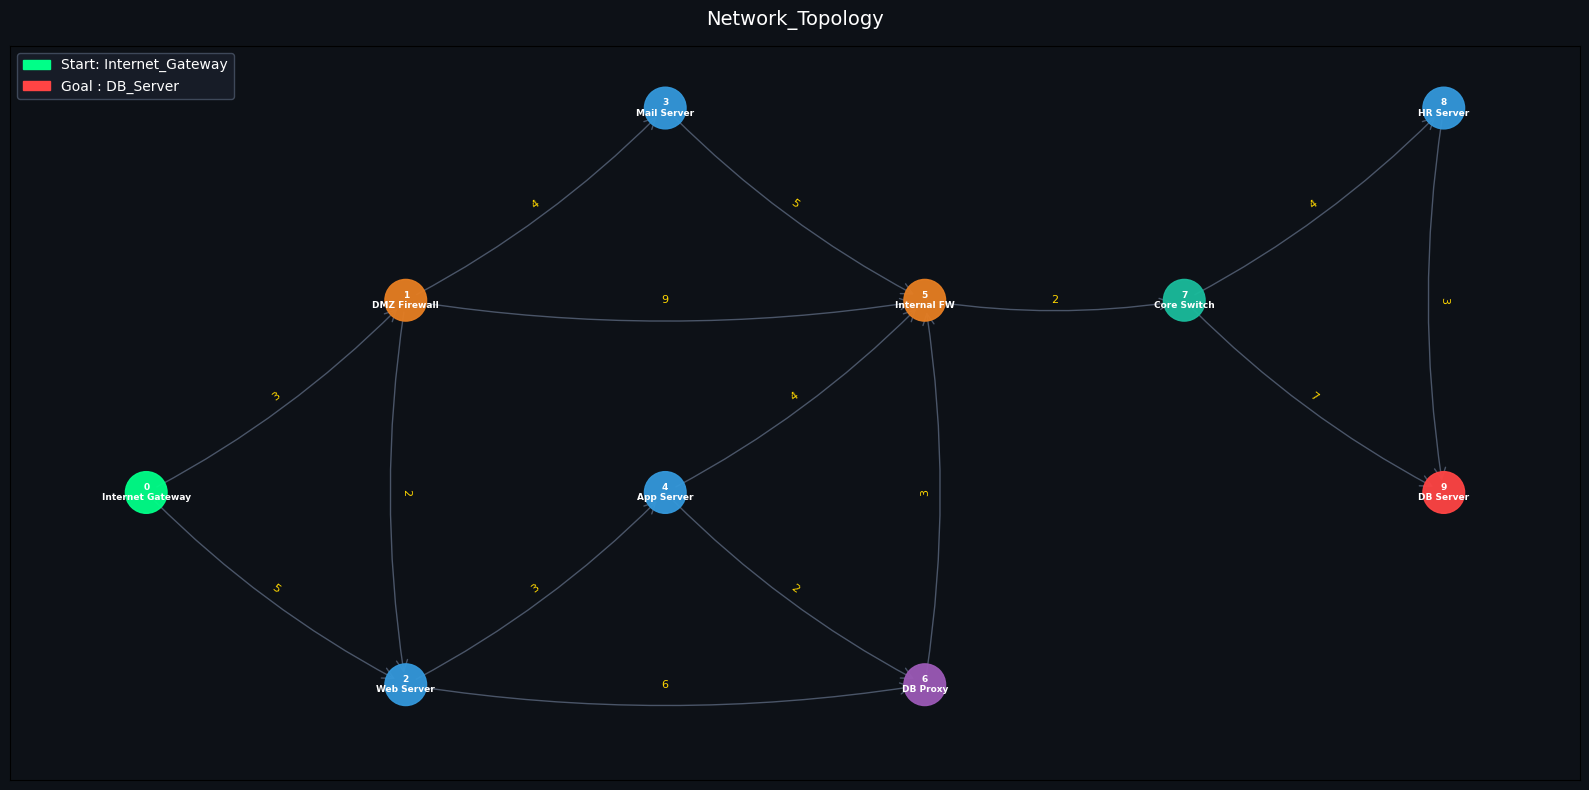

   Saved → /content/Network_Topology.png


In [3]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 3 — Visualise the Network                 ║
# ╚══════════════════════════════════════════════════╝

NODE_COLORS = {
    'Gateway':  '#e74c3c',
    'Firewall': '#e67e22',
    'Server':   '#3498db',
    'Proxy':    '#9b59b6',
    'Switch':   '#1abc9c',
    'Database': '#e74c3c',
}

# Fixed layout positions
POS = {
    0:(0,2), 1:(2,3), 2:(2,1),
    3:(4,4), 4:(4,2),
    5:(6,3), 6:(6,1),
    7:(8,3), 8:(10,4), 9:(10,2)
}

def draw_network(highlight_path=None, title='Network Topology'):
    fig, ax = plt.subplots(figsize=(16,8))
    ax.set_facecolor('#0d1117')
    fig.patch.set_facecolor('#0d1117')

    # Node colours
    colors = []
    for n in G.nodes():
        if n == START:   colors.append('#00ff88')
        elif n == GOAL:  colors.append('#ff4444')
        else:            colors.append(NODE_COLORS.get(NODES[n]['type'], '#7f8c8d'))

    # Edge colours — highlight path
    path_edges = set()
    if highlight_path:
        path_edges = set(zip(highlight_path, highlight_path[1:]))
    edge_colors = ['#00ff88' if (u,v) in path_edges else '#4a5568' for u,v in G.edges()]
    edge_widths = [3.5 if (u,v) in path_edges else 1.0 for u,v in G.edges()]

    nx.draw_networkx_edges(G, POS, ax=ax, edge_color=edge_colors, width=edge_widths,
                           arrows=True, arrowstyle='->', arrowsize=20,
                           connectionstyle='arc3,rad=0.08')
    nx.draw_networkx_nodes(G, POS, ax=ax, node_color=colors, node_size=900, alpha=0.95)

    labels = {n: f"{n}\n{NODES[n]['name'].replace('_',' ')}" for n in G.nodes()}
    nx.draw_networkx_labels(G, POS, labels, ax=ax, font_size=6.5,
                            font_color='white', font_weight='bold')

    edge_labels = {(u,v): d['weight'] for u,v,d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, POS, edge_labels, ax=ax,
                                 font_size=8, font_color='#ffd700',
                                 bbox=dict(alpha=0))

    legend_elems = [
        mpatches.Patch(color='#00ff88', label=f'Start: {NODES[START]["name"]}'),
        mpatches.Patch(color='#ff4444', label=f'Goal : {NODES[GOAL]["name"]}'),
    ]
    if highlight_path:
        legend_elems.append(mpatches.Patch(color='#00ff88', label='Attack Path'))

    ax.legend(handles=legend_elems, loc='upper left',
              facecolor='#1a202c', edgecolor='#4a5568', labelcolor='white')
    ax.set_title(title, color='white', fontsize=14, pad=15)
    plt.tight_layout()
    safe = title.replace(' ','_').replace('*','Star')
    plt.savefig(f'/content/{safe}.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f'   Saved → /content/{safe}.png')

draw_network(title='Network_Topology')

## 🔵 Algorithm 1 — Breadth-First Search (BFS)
**Uninformed search.** Explores layer by layer using a FIFO queue.  
Finds the path with the **fewest hops**, NOT minimum cost.

═══════════════════════════════════════════════════════
  BREADTH-FIRST SEARCH (BFS) RESULTS
═══════════════════════════════════════════════════════
  Path     : Internet_Gateway → DMZ_Firewall → Internal_FW → Core_Switch → DB_Server
  Cost     : 21
  Expanded : 10 nodes
  Time     : 0.0837 ms


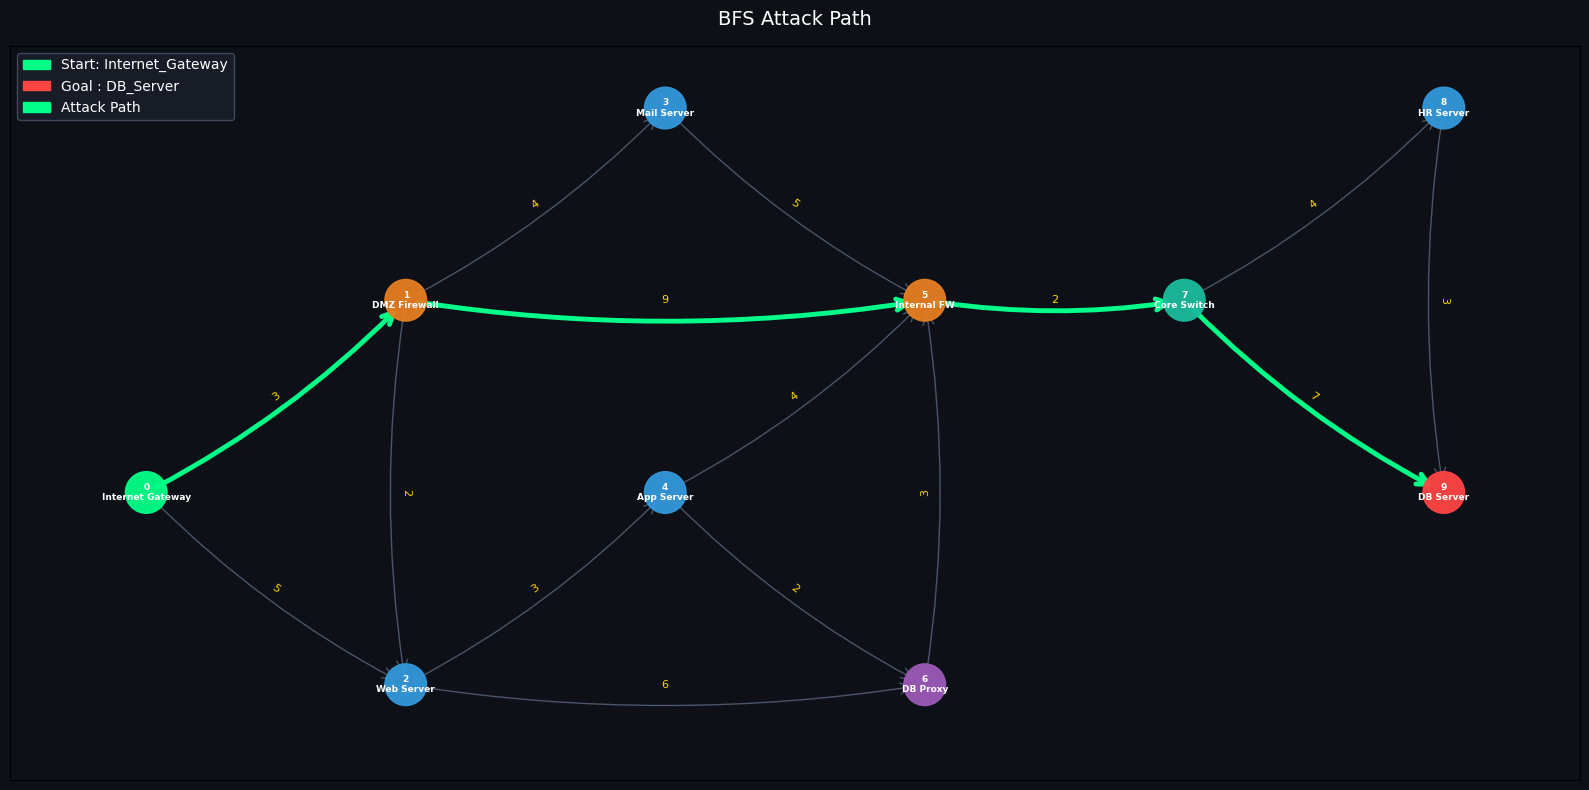

   Saved → /content/BFS_Attack_Path.png


In [4]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 4 — Breadth-First Search (BFS)            ║
# ╚══════════════════════════════════════════════════╝

def reconstruct(parent, goal):
    path, node = [], goal
    while node is not None:
        path.append(node)
        node = parent[node]
    return list(reversed(path))

def bfs(start, goal):
    t0 = time.perf_counter()
    queue    = deque([start])
    visited  = {start}
    parent   = {start: None}
    expanded = 0
    while queue:
        node = queue.popleft()
        expanded += 1
        if node == goal:
            path = reconstruct(parent, goal)
            return path, path_cost(path), expanded, (time.perf_counter()-t0)*1000
        for nb, _ in get_neighbors(node):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = node
                queue.append(nb)
    return None, float('inf'), expanded, (time.perf_counter()-t0)*1000

bfs_path, bfs_cost, bfs_exp, bfs_ms = bfs(START, GOAL)

print('═'*55)
print('  BREADTH-FIRST SEARCH (BFS) RESULTS')
print('═'*55)
print(f'  Path     : {" → ".join(node_name(n) for n in bfs_path)}')
print(f'  Cost     : {bfs_cost}')
print(f'  Expanded : {bfs_exp} nodes')
print(f'  Time     : {bfs_ms:.4f} ms')

draw_network(bfs_path, 'BFS Attack Path')

## 🟠 Algorithm 2 — Depth-First Search (DFS)
**Uninformed search.** Explores as deep as possible before backtracking (LIFO stack).  
NOT guaranteed to find the minimum cost path.

═══════════════════════════════════════════════════════
  DEPTH-FIRST SEARCH (DFS) RESULTS
═══════════════════════════════════════════════════════
  Path     : Internet_Gateway → Web_Server → DB_Proxy → Internal_FW → Core_Switch → DB_Server
  Cost     : 23
  Expanded : 6 nodes
  Time     : 0.0485 ms


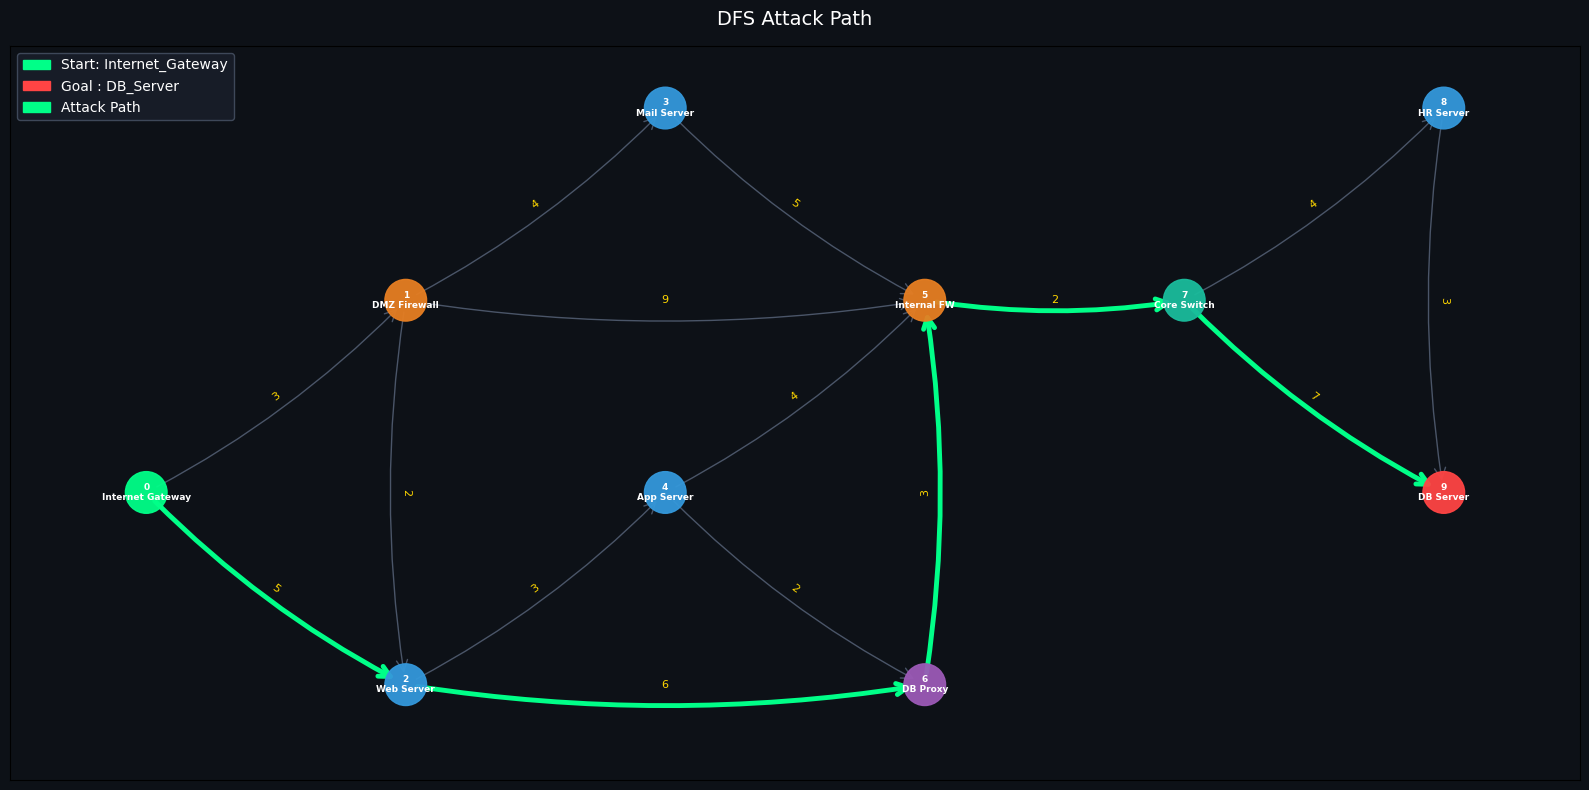

   Saved → /content/DFS_Attack_Path.png


In [5]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 5 — Depth-First Search (DFS)              ║
# ╚══════════════════════════════════════════════════╝

def dfs(start, goal):
    t0 = time.perf_counter()
    stack    = [start]
    visited  = set()
    parent   = {start: None}
    expanded = 0
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        expanded += 1
        if node == goal:
            path = reconstruct(parent, goal)
            return path, path_cost(path), expanded, (time.perf_counter()-t0)*1000
        for nb, _ in get_neighbors(node):
            if nb not in visited:
                parent[nb] = node
                stack.append(nb)
    return None, float('inf'), expanded, (time.perf_counter()-t0)*1000

dfs_path, dfs_cost, dfs_exp, dfs_ms = dfs(START, GOAL)

print('═'*55)
print('  DEPTH-FIRST SEARCH (DFS) RESULTS')
print('═'*55)
print(f'  Path     : {" → ".join(node_name(n) for n in dfs_path)}')
print(f'  Cost     : {dfs_cost}')
print(f'  Expanded : {dfs_exp} nodes')
print(f'  Time     : {dfs_ms:.4f} ms')

draw_network(dfs_path, 'DFS Attack Path')

## 🟡 Algorithm 3 — Uniform Cost Search (UCS)
**Informed (cost-based) search.** Expands the lowest-cost frontier node using a min-heap.  
Guarantees the **optimal minimum-cost** path.

═══════════════════════════════════════════════════════
  UNIFORM COST SEARCH (UCS) RESULTS
═══════════════════════════════════════════════════════
  Path     : Internet_Gateway → DMZ_Firewall → Web_Server → App_Server → Internal_FW → Core_Switch → HR_Server → DB_Server
  Cost     : 21
  Expanded : 10 nodes
  Time     : 0.0663 ms


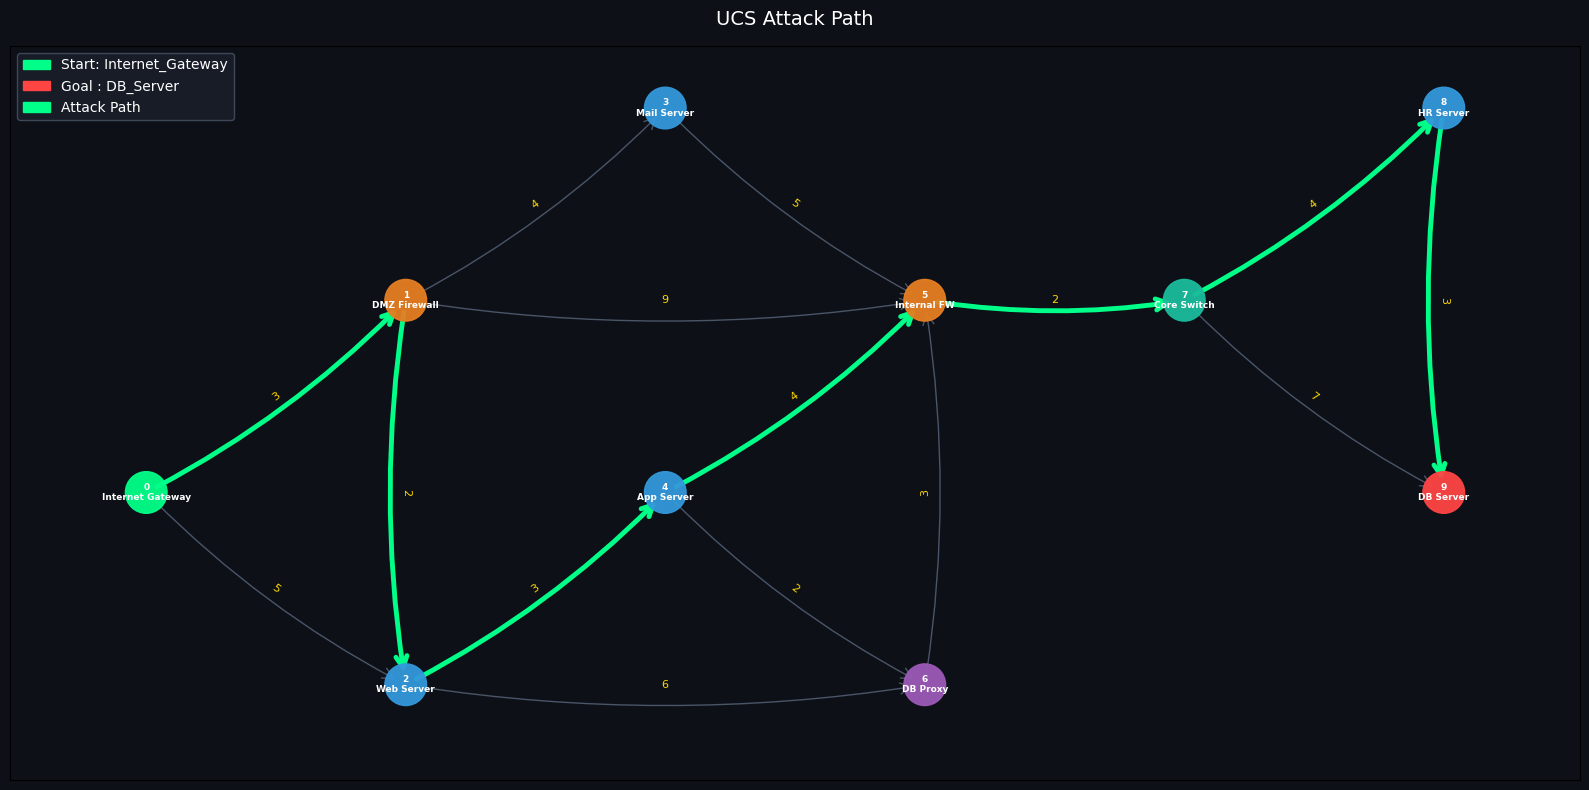

   Saved → /content/UCS_Attack_Path.png


In [6]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 6 — Uniform Cost Search (UCS)             ║
# ╚══════════════════════════════════════════════════╝

def ucs(start, goal):
    t0 = time.perf_counter()
    heap     = [(0, start, [start])]  # (cost, node, path)
    visited  = {}
    expanded = 0
    while heap:
        cost, node, path = heapq.heappop(heap)
        if node in visited:
            continue
        visited[node] = cost
        expanded += 1
        if node == goal:
            return path, cost, expanded, (time.perf_counter()-t0)*1000
        for nb, w in get_neighbors(node):
            if nb not in visited:
                heapq.heappush(heap, (cost+w, nb, path+[nb]))
    return None, float('inf'), expanded, (time.perf_counter()-t0)*1000

ucs_path, ucs_cost, ucs_exp, ucs_ms = ucs(START, GOAL)

print('═'*55)
print('  UNIFORM COST SEARCH (UCS) RESULTS')
print('═'*55)
print(f'  Path     : {" → ".join(node_name(n) for n in ucs_path)}')
print(f'  Cost     : {ucs_cost}')
print(f'  Expanded : {ucs_exp} nodes')
print(f'  Time     : {ucs_ms:.4f} ms')

draw_network(ucs_path, 'UCS Attack Path')

## 🟢 Algorithm 4 — A* Search
**Heuristic-guided search.** Uses $f(n) = g(n) + h(n)$.

**Heuristic design:**  
$h(n) = R_{max} - r(n)$ where $R_{max}=10$ and $r(n)$ is node risk.  
Higher-risk nodes are closer to the sensitive data core → lower estimated remaining cost.  
This heuristic is **admissible** (never overestimates).

═══════════════════════════════════════════════════════
  A* SEARCH RESULTS
═══════════════════════════════════════════════════════
  Path     : Internet_Gateway → DMZ_Firewall → Web_Server → App_Server → Internal_FW → Core_Switch → DB_Server
  Cost     : 21
  Expanded : 9 nodes
  Time     : 0.0750 ms


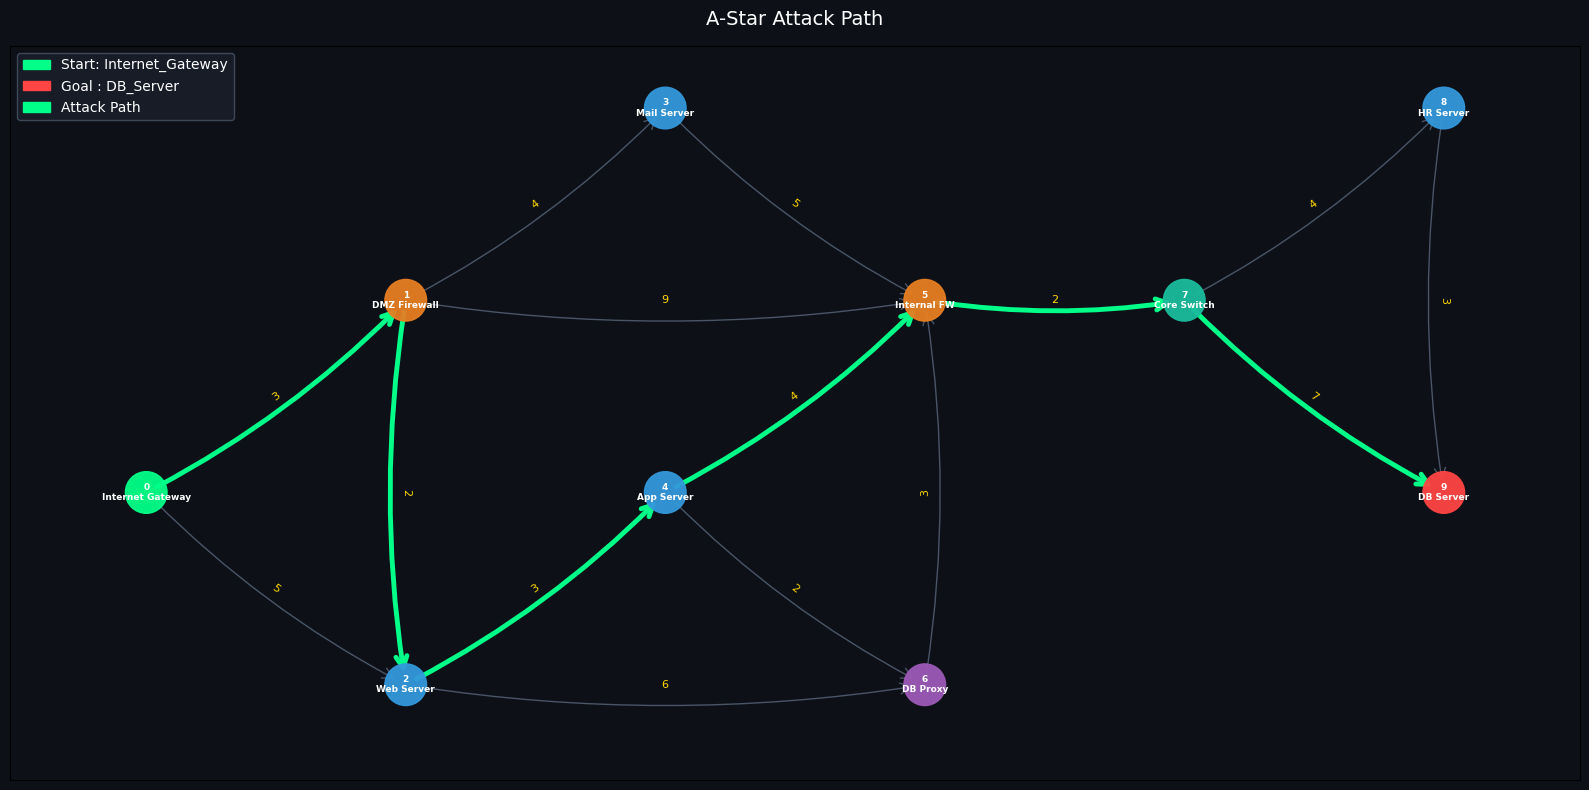

   Saved → /content/A-Star_Attack_Path.png


In [7]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 7 — A* Search Algorithm                  ║
# ╚══════════════════════════════════════════════════╝

MAX_RISK = max(NODES[n]['risk'] for n in NODES)

def heuristic(n):
    """h(n) = MAX_RISK - risk(n)  →  admissible, domain-informed."""
    return MAX_RISK - NODES[n]['risk']

def astar(start, goal):
    t0 = time.perf_counter()
    heap     = [(heuristic(start), 0, start, [start])]  # (f, g, node, path)
    visited  = {}
    expanded = 0
    while heap:
        f, g, node, path = heapq.heappop(heap)
        if node in visited:
            continue
        visited[node] = g
        expanded += 1
        if node == goal:
            return path, g, expanded, (time.perf_counter()-t0)*1000
        for nb, w in get_neighbors(node):
            if nb not in visited:
                ng = g + w
                heapq.heappush(heap, (ng + heuristic(nb), ng, nb, path+[nb]))
    return None, float('inf'), expanded, (time.perf_counter()-t0)*1000

astar_path, astar_cost, astar_exp, astar_ms = astar(START, GOAL)

print('═'*55)
print('  A* SEARCH RESULTS')
print('═'*55)
print(f'  Path     : {" → ".join(node_name(n) for n in astar_path)}')
print(f'  Cost     : {astar_cost}')
print(f'  Expanded : {astar_exp} nodes')
print(f'  Time     : {astar_ms:.4f} ms')

draw_network(astar_path, 'A-Star Attack Path')

## 🔴 Algorithm 5 — Hill Climbing (Local Search)
Greedy local search — always moves to the neighbour with the **lowest heuristic value**.  
**No backtracking** — can get stuck at local optima.

We also demonstrate the **local optimum trap** with a custom sub-graph.

═══════════════════════════════════════════════════════
  HILL CLIMBING RESULTS
═══════════════════════════════════════════════════════
  Status   : ✅ SUCCESS
  Path     : Internet_Gateway → DMZ_Firewall → Internal_FW → Core_Switch → DB_Server
  Cost     : 21
  Expanded : 4 nodes
  Time     : 0.0521 ms


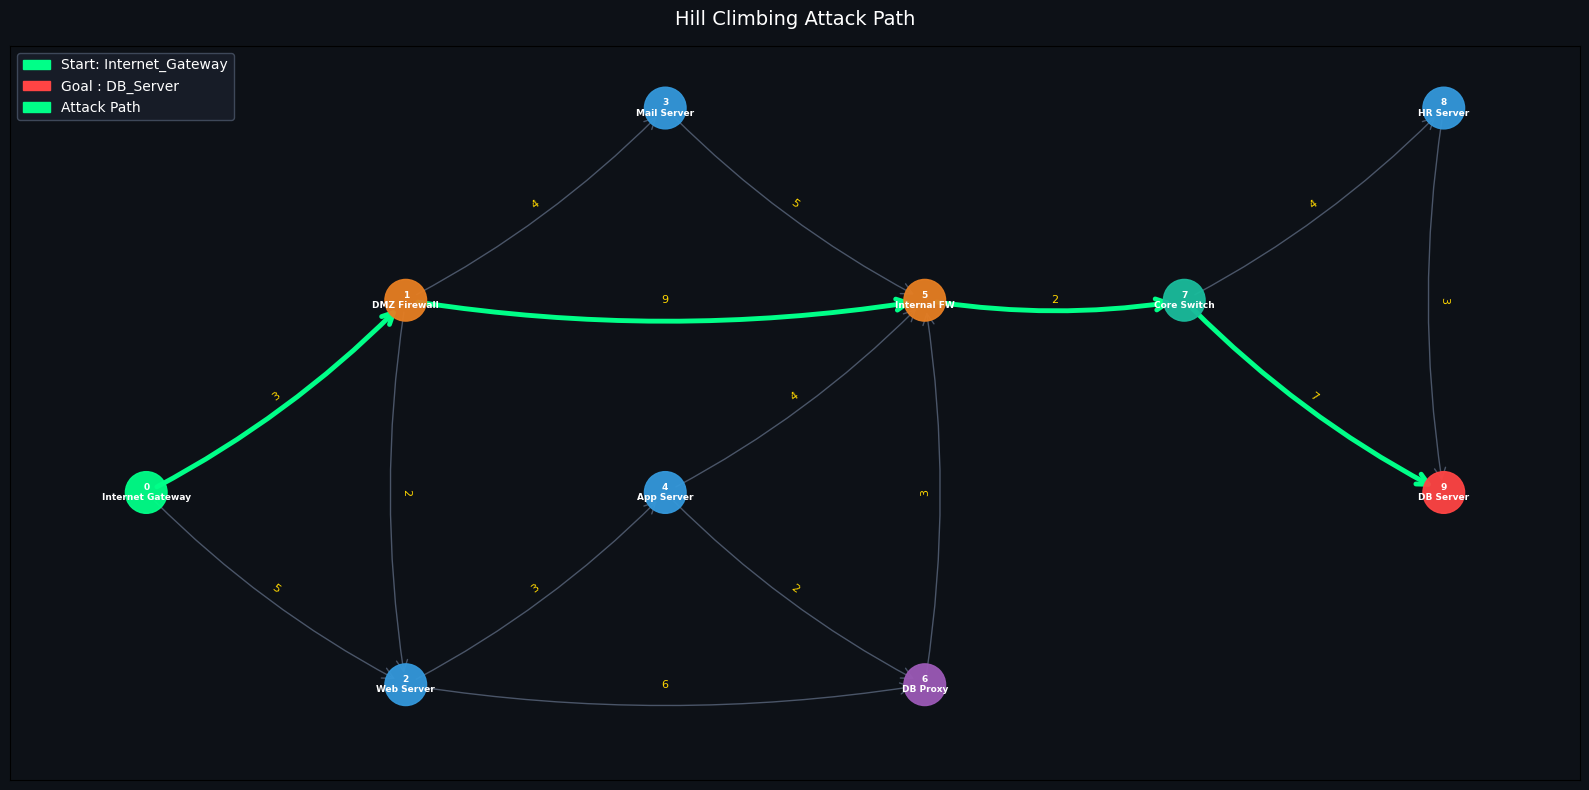

   Saved → /content/Hill_Climbing_Attack_Path.png

═══════════════════════════════════════════════════════
  LOCAL OPTIMUM TRAP DEMO
═══════════════════════════════════════════════════════
Graph: 0→1→2(dead end), 0→3→4(goal)
Hill Climbing picks 1 (better h) over 3,
reaches 2 which is a dead end → STUCK!

  Trap Path : [0, 1, 2]
  Result    : ❌ STUCK at local optimum — Goal UNREACHABLE!


In [8]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 8 — Hill Climbing + Local Optimum Demo    ║
# ╚══════════════════════════════════════════════════╝

def hill_climbing(start, goal):
    t0      = time.perf_counter()
    current = start
    path    = [current]
    visited = {current}
    expanded= 0
    while current != goal:
        neighbours = [(nb, heuristic(nb)) for nb, _ in get_neighbors(current)
                      if nb not in visited]
        expanded += 1
        if not neighbours:
            return path, path_cost(path), expanded, (time.perf_counter()-t0)*1000, '⚠️  STUCK — local optimum!'
        current = min(neighbours, key=lambda x: x[1])[0]
        path.append(current)
        visited.add(current)
    return path, path_cost(path), expanded, (time.perf_counter()-t0)*1000, '✅ SUCCESS'

hc_path, hc_cost, hc_exp, hc_ms, hc_status = hill_climbing(START, GOAL)

print('═'*55)
print('  HILL CLIMBING RESULTS')
print('═'*55)
print(f'  Status   : {hc_status}')
print(f'  Path     : {" → ".join(node_name(n) for n in hc_path)}')
print(f'  Cost     : {hc_cost}')
print(f'  Expanded : {hc_exp} nodes')
print(f'  Time     : {hc_ms:.4f} ms')

draw_network(hc_path, 'Hill Climbing Attack Path')

# ──────────────────────────────────────────────
#   LOCAL OPTIMUM TRAP DEMONSTRATION
# ──────────────────────────────────────────────
print('\n' + '═'*55)
print('  LOCAL OPTIMUM TRAP DEMO')
print('═'*55)
print('Graph: 0→1→2(dead end), 0→3→4(goal)')
print('Hill Climbing picks 1 (better h) over 3,')
print('reaches 2 which is a dead end → STUCK!\n')

TRAP = nx.DiGraph()
for n, r in [(0,4),(1,6),(2,8),(3,5),(4,9)]:
    TRAP.add_node(n, risk=r, name=f'TrapNode_{n}')
TRAP.add_edge(0,1,weight=1)  # h(1)=2 — looks great
TRAP.add_edge(1,2,weight=1)  # h(2)=1 — even better — but DEAD END
TRAP.add_edge(0,3,weight=3)  # h(3)=4 — skipped initially
TRAP.add_edge(3,4,weight=1)  # goal reachable only via node 3

def trap_h(n): return 10 - TRAP.nodes[n]['risk']

def hc_trap(g, start, goal):
    current = start; path = [current]; visited = {current}
    while current != goal:
        nbs = [(nb, trap_h(nb)) for nb in g.successors(current) if nb not in visited]
        if not nbs:
            return path, '❌ STUCK at local optimum — Goal UNREACHABLE!'
        current = min(nbs, key=lambda x: x[1])[0]
        path.append(current)
        visited.add(current)
    return path, '✅ GOAL REACHED'

trap_path, trap_status = hc_trap(TRAP, 0, 4)
print(f'  Trap Path : {trap_path}')
print(f'  Result    : {trap_status}')

## ⚔️ Algorithms 6 & 7 — Minimax + Alpha-Beta Pruning
**Two-player adversarial model:**
- **Attacker (MAX)** — wants to reach DB_Server at minimum cost
- **Defender (MIN)** — tries to increase cost / block paths

**Alpha-Beta Pruning** eliminates branches that cannot affect the final decision, reducing node evaluations by ~50%.

═══════════════════════════════════════════════════════
  MINIMAX RESULTS
═══════════════════════════════════════════════════════
  Path     : Internet_Gateway → DMZ_Firewall → Mail_Server → Internal_FW → Core_Switch
  Score    : -28
  Expanded : 24 nodes
  Time     : 0.2694 ms

═══════════════════════════════════════════════════════
  ALPHA-BETA PRUNING RESULTS
═══════════════════════════════════════════════════════
  Path     : Internet_Gateway → DMZ_Firewall → Mail_Server → Internal_FW → Core_Switch
  Score    : -28
  Expanded : 24 nodes
  Time     : 0.4633 ms

  ✂️  Pruning saved: 0.0% fewer node evaluations


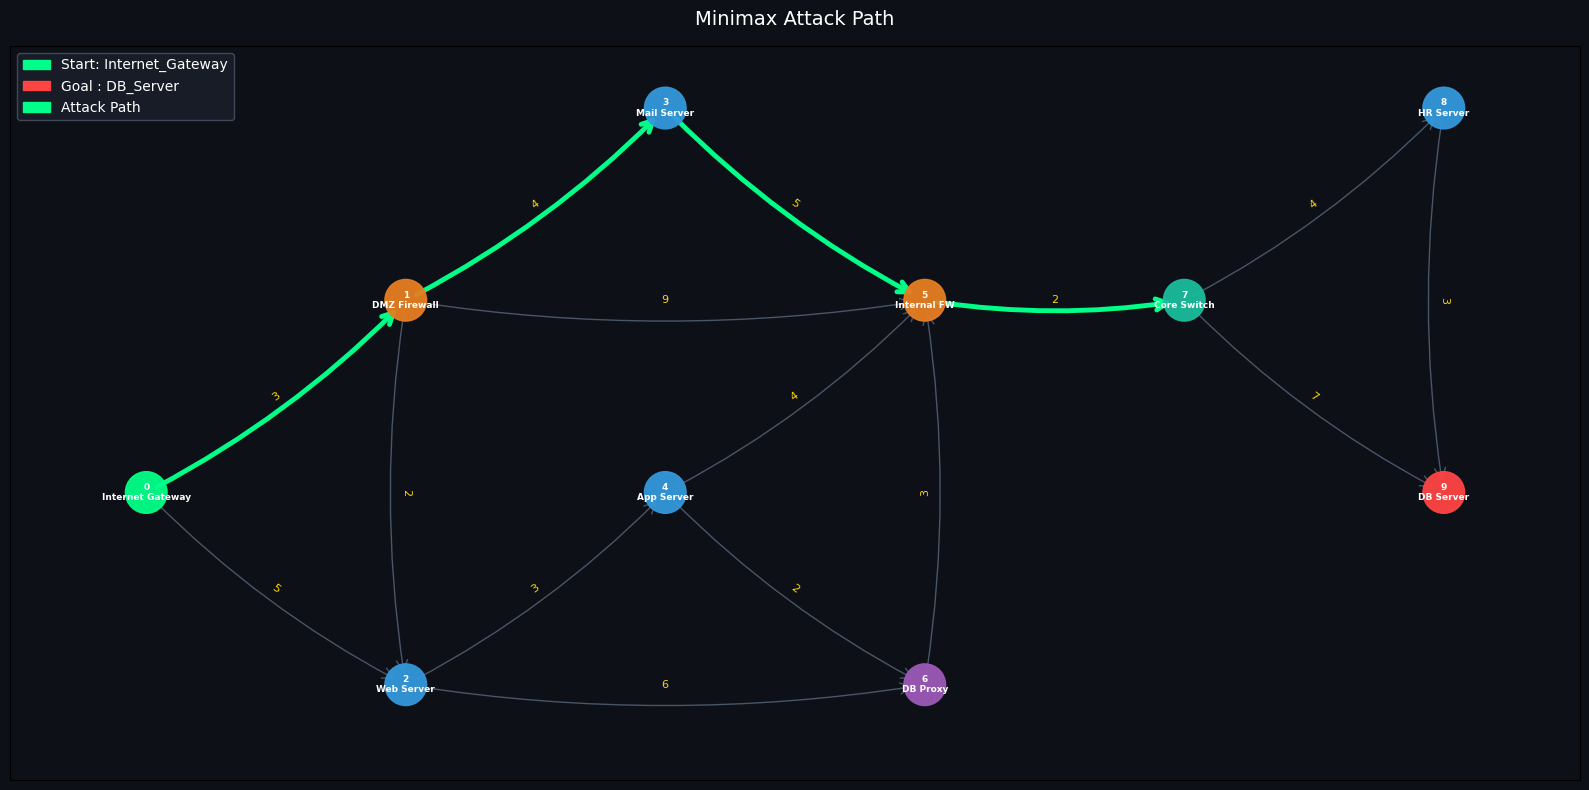

   Saved → /content/Minimax_Attack_Path.png


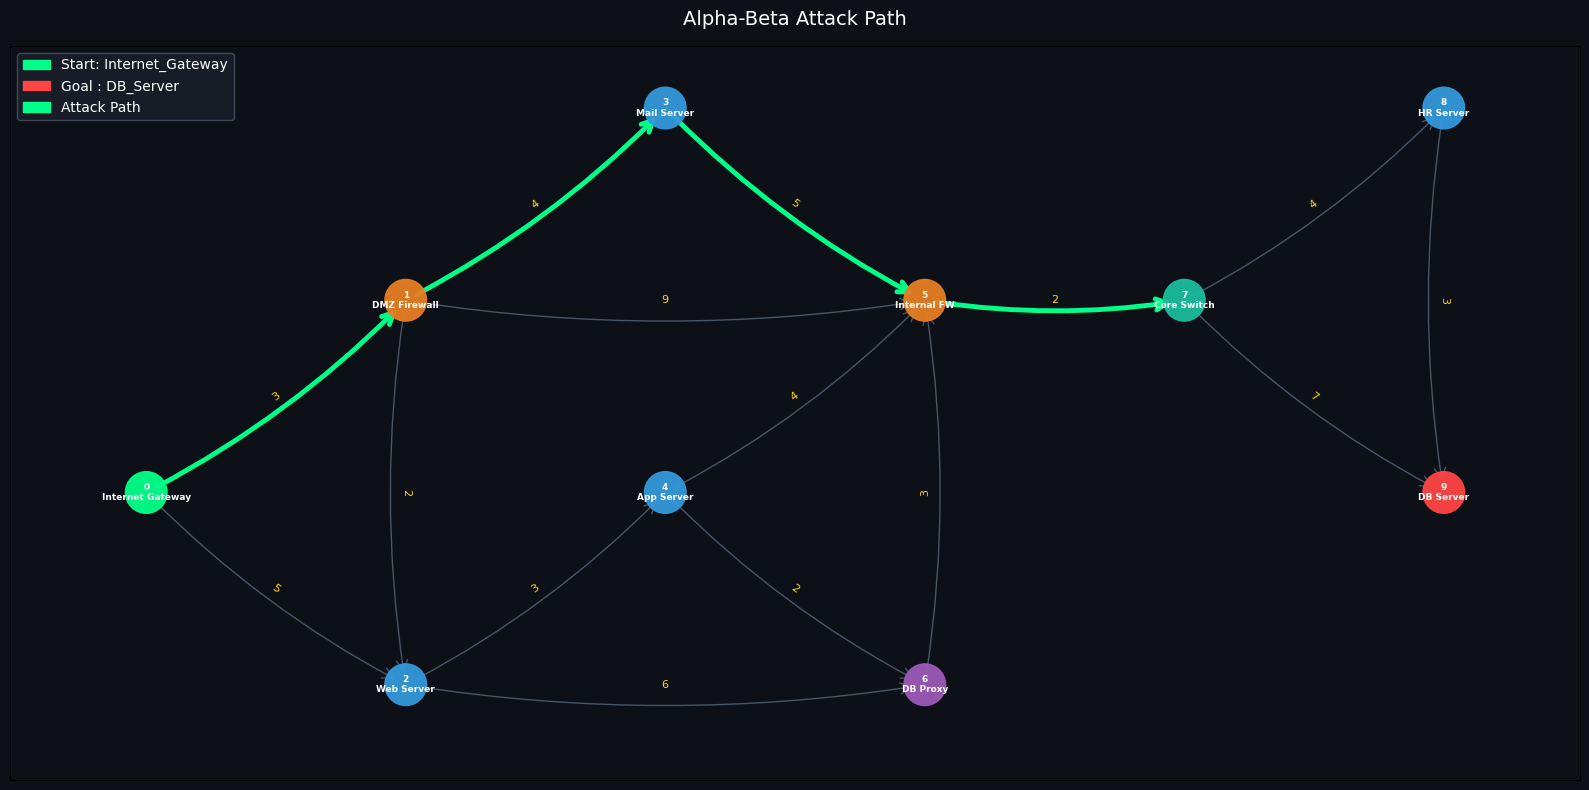

   Saved → /content/Alpha-Beta_Attack_Path.png


In [9]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 9 — Minimax + Alpha-Beta Pruning          ║
# ╚══════════════════════════════════════════════════╝

DEPTH = 4  # Search depth (levels of attacker/defender alternation)

def evaluate(node, cost):
    """Terminal node evaluation. Attacker wants high score (=low cost)."""
    return -(cost + 2 * heuristic(node))

# ── Minimax ──────────────────────────────────────
minimax_count = [0]

def minimax(node, depth, is_max, cost, visited):
    minimax_count[0] += 1
    nbs = [(nb, G[node][nb]['weight']) for nb in G.successors(node) if nb not in visited]
    if depth == 0 or node == GOAL or not nbs:
        return evaluate(node, cost), [node]
    if is_max:
        best, best_p = -math.inf, [node]
        for nb, w in nbs:
            val, p = minimax(nb, depth-1, False, cost+w, visited|{nb})
            if val > best: best, best_p = val, [node]+p
        return best, best_p
    else:
        best, best_p = math.inf, [node]
        for nb, w in nbs:
            val, p = minimax(nb, depth-1, True, cost+w, visited|{nb})
            if val < best: best, best_p = val, [node]+p
        return best, best_p

# ── Alpha-Beta Pruning ───────────────────────────
ab_count = [0]

def alphabeta(node, depth, alpha, beta, is_max, cost, visited):
    ab_count[0] += 1
    nbs = [(nb, G[node][nb]['weight']) for nb in G.successors(node) if nb not in visited]
    if depth == 0 or node == GOAL or not nbs:
        return evaluate(node, cost), [node]
    if is_max:
        best, best_p = -math.inf, [node]
        for nb, w in nbs:
            val, p = alphabeta(nb, depth-1, alpha, beta, False, cost+w, visited|{nb})
            if val > best: best, best_p = val, [node]+p
            alpha = max(alpha, best)
            if beta <= alpha: break  # Beta cutoff — prune
        return best, best_p
    else:
        best, best_p = math.inf, [node]
        for nb, w in nbs:
            val, p = alphabeta(nb, depth-1, alpha, beta, True, cost+w, visited|{nb})
            if val < best: best, best_p = val, [node]+p
            beta = min(beta, best)
            if beta <= alpha: break  # Alpha cutoff — prune
        return best, best_p

# ── Run both ─────────────────────────────────────
t0 = time.perf_counter()
mm_val,  mm_path  = minimax(START, DEPTH, True, 0, {START})
mm_ms   = (time.perf_counter()-t0)*1000
mm_exp  = minimax_count[0]

t0 = time.perf_counter()
ab_val,  ab_path  = alphabeta(START, DEPTH, -math.inf, math.inf, True, 0, {START})
ab_ms   = (time.perf_counter()-t0)*1000
ab_exp  = ab_count[0]

print('═'*55)
print('  MINIMAX RESULTS')
print('═'*55)
print(f'  Path     : {" → ".join(node_name(n) for n in mm_path)}')
print(f'  Score    : {mm_val}')
print(f'  Expanded : {mm_exp} nodes')
print(f'  Time     : {mm_ms:.4f} ms')
print()
print('═'*55)
print('  ALPHA-BETA PRUNING RESULTS')
print('═'*55)
print(f'  Path     : {" → ".join(node_name(n) for n in ab_path)}')
print(f'  Score    : {ab_val}')
print(f'  Expanded : {ab_exp} nodes')
print(f'  Time     : {ab_ms:.4f} ms')
saving = ((mm_exp-ab_exp)/mm_exp)*100 if mm_exp > 0 else 0
print(f'\n  ✂️  Pruning saved: {saving:.1f}% fewer node evaluations')

draw_network(mm_path, 'Minimax Attack Path')
draw_network(ab_path, 'Alpha-Beta Attack Path')

## 📊 Comparative Analysis — All Algorithms


   COMPARATIVE ANALYSIS TABLE
Algorithm            Discovered Path                Total Cost     Nodes Expanded     Time (ms)
------------------------------------------------------------------------------------------
BFS                  0→1→5→7→9                      21             10                 0.0837
DFS                  0→2→6→5→7→9                    23             6                  0.0485
UCS                  0→1→2→4→5→7→8→9                21             10                 0.0663
A* Search            0→1→2→4→5→7→9                  21             9                  0.0750
Hill Climbing        0→1→5→7→9                      21             4                  0.0521
Minimax              0→1→3→5→7                      14             24                 0.2694
Alpha-Beta           0→1→3→5→7                      14             24                 0.4633


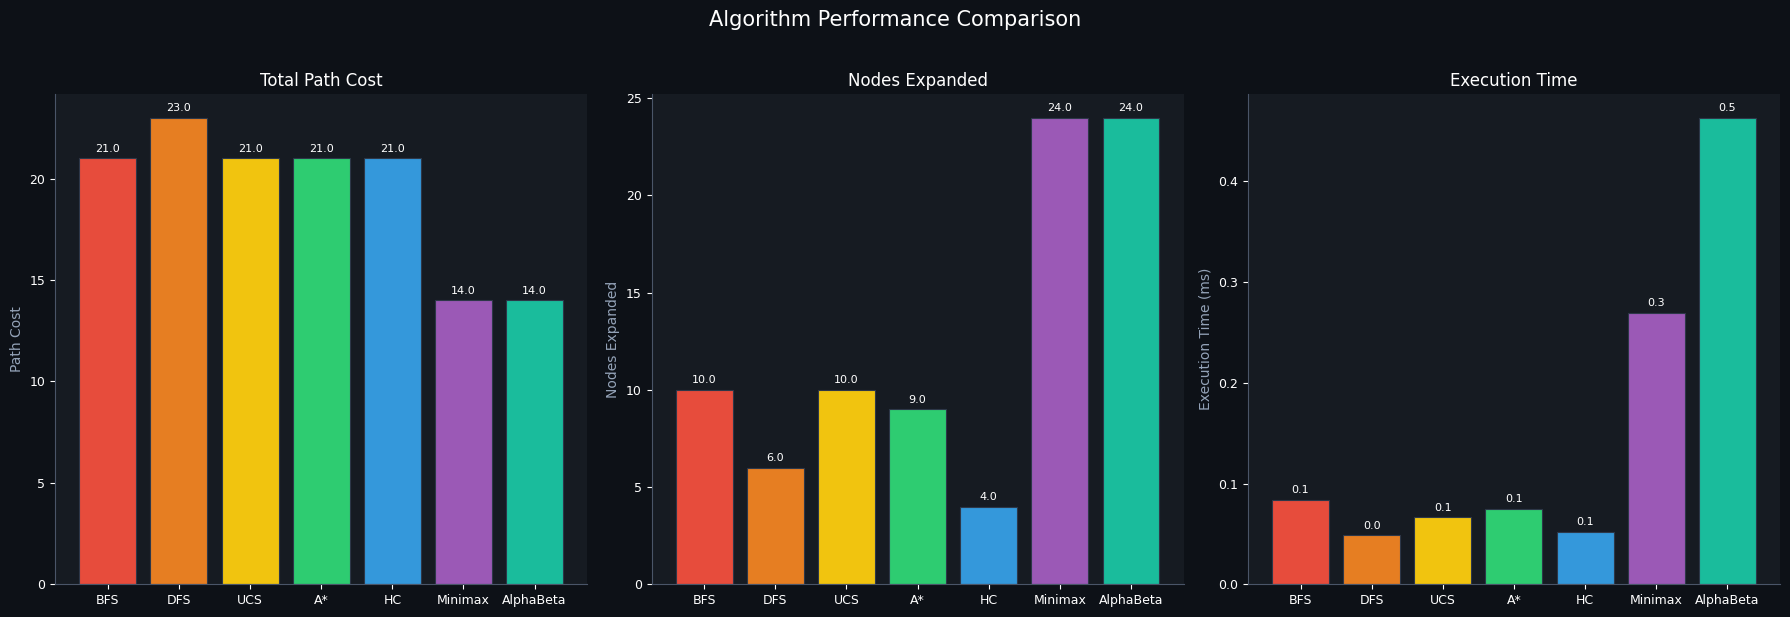


✅ ALL ALGORITHMS COMPLETE!
   Saved PNGs → /content/*.png
   Download them via Files panel on the left sidebar.


In [10]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 10 — Comparative Analysis Table & Charts  ║
# ╚══════════════════════════════════════════════════╝

# ── Print table ──────────────────────────────────
print('\n' + '='*90)
print('   COMPARATIVE ANALYSIS TABLE')
print('='*90)
header = f'{"Algorithm":<20} {"Discovered Path":<30} {"Total Cost":<14} {"Nodes Expanded":<18} {"Time (ms)"}'
print(header)
print('-'*90)

def fp(path): return '→'.join(str(n) for n in path) if path else 'None'

rows = [
    ('BFS',           bfs_path,   bfs_cost,              bfs_exp,  bfs_ms),
    ('DFS',           dfs_path,   dfs_cost,              dfs_exp,  dfs_ms),
    ('UCS',           ucs_path,   ucs_cost,              ucs_exp,  ucs_ms),
    ('A* Search',     astar_path, astar_cost,            astar_exp,astar_ms),
    ('Hill Climbing', hc_path,    hc_cost,               hc_exp,   hc_ms),
    ('Minimax',       mm_path,    path_cost(mm_path),    mm_exp,   mm_ms),
    ('Alpha-Beta',    ab_path,    path_cost(ab_path),    ab_exp,   ab_ms),
]
for alg, path, cost, exp, ms in rows:
    print(f'{alg:<20} {fp(path):<30} {cost:<14} {exp:<18} {ms:.4f}')
print('='*90)

# ── Bar charts ───────────────────────────────────
labels   = ['BFS','DFS','UCS','A*','HC','Minimax','AlphaBeta']
costs_v  = [r[2] for r in rows]
expanded = [r[3] for r in rows]
times_v  = [r[4] for r in rows]
clrs     = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.patch.set_facecolor('#0d1117')

for ax, data, ylabel, ttl in zip(
        axes,
        [costs_v, expanded, times_v],
        ['Path Cost','Nodes Expanded','Execution Time (ms)'],
        ['Total Path Cost','Nodes Expanded','Execution Time']):
    bars = ax.bar(labels, data, color=clrs, edgecolor='#2d3748', linewidth=0.8)
    ax.set_facecolor('#161b22')
    ax.set_title(ttl, color='white', fontsize=12)
    ax.set_ylabel(ylabel, color='#94a3b8')
    ax.tick_params(colors='white', labelsize=9)
    ax.spines[['top','right']].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#4a5568')
    for bar, val in zip(bars, data):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(data)*0.01,
                f'{val:.1f}', ha='center', va='bottom', color='white', fontsize=8)

plt.suptitle('Algorithm Performance Comparison', color='white', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('/content/Comparison_Chart.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('\n✅ ALL ALGORITHMS COMPLETE!')
print('   Saved PNGs → /content/*.png')
print('   Download them via Files panel on the left sidebar.')